<a href="https://colab.research.google.com/github/antonDinkov/AI_integrationsForDev/blob/main/regular_examen/Regular_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Initializing

In [15]:
!pip install -q -U chromadb openai pypdf google-genai elevenlabs pydantic

In [4]:
import base64
import json
import os
import re
import uuid

from pathlib import Path
from typing import Literal

import chromadb

from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction
from elevenlabs import ElevenLabs
from google import genai
from IPython.display import Audio, Image, display
from openai import OpenAI
from pydantic import BaseModel, Field
from pypdf import PdfReader

## API keys and model configuration

In [5]:
from google.colab import userdata


def get_secret(secret_name: str) -> str:
    """
    Read an API key from Google Colab Secrets.

    If the notebook is executed outside Colab, the function tries
    to read the same value from an environment variable.
    """

    value = None

    try:
        value = userdata.get(secret_name)
    except Exception:
        value = os.getenv(secret_name)

    if not value:
        raise RuntimeError(
            f"Missing secret: {secret_name}. "
            "Add it to Google Colab Secrets."
        )

    return value


OPENAI_API_KEY = get_secret("OPEN_AI_API_KEY")
GEMINI_API_KEY = get_secret("Gemini_API_Key")
ELEVENLABS_API_KEY = get_secret("ELEVENLABS_API_KEY")

In [6]:
OPENAI_TEXT_MODEL = "gpt-5.4-nano-2026-03-17"
OPENAI_EMBEDDING_MODEL = "text-embedding-3-small"

GEMINI_IMAGE_MODEL = "gemini-3.1-flash-lite-image"

ELEVENLABS_TTS_MODEL = "eleven_flash_v2_5"

ELEVENLABS_VOICE_ID = "zX2tU5GM7OSuYa2xQ0Bc"

PDF_PATH = Path(
    "/content/euclid's_book_on_division_of_figures-pdf.pdf"
)

CHROMA_PATH = "/content/euclid_chroma_database"
COLLECTION_NAME = "euclid_divisions_collection"

CHUNK_SIZE = 1400
CHUNK_OVERLAP = 250
RETRIEVAL_RESULTS_COUNT = 6

MAX_HISTORY_MESSAGES = 8

In [7]:
openai_client = OpenAI(
    api_key=OPENAI_API_KEY
)

gemini_client = genai.Client(
    api_key=GEMINI_API_KEY
)

elevenlabs_client = ElevenLabs(
    api_key=ELEVENLABS_API_KEY
)

print("API clients initialized successfully.")

API clients initialized successfully.


## Extract content from the PDF file

In [8]:
if not PDF_PATH.exists():
    from google.colab import files

    print(
        "Upload the PDF file. The expected filename is:\n"
        f"{PDF_PATH.name}"
    )

    uploaded_files = files.upload()

    if not uploaded_files:
        raise FileNotFoundError(
            "No PDF file was uploaded."
        )

    uploaded_filename = next(iter(uploaded_files))
    PDF_PATH = Path("/content") / uploaded_filename


if PDF_PATH.suffix.lower() != ".pdf":
    raise ValueError(
        "The uploaded source must be a PDF file."
    )

print(f"Using PDF: {PDF_PATH}")

Upload the PDF file. The expected filename is:
euclid's_book_on_division_of_figures-pdf.pdf


Saving euclid's_book_on_division_of_figures-pdf.pdf to euclid's_book_on_division_of_figures-pdf.pdf
Using PDF: /content/euclid's_book_on_division_of_figures-pdf.pdf


In [9]:
pdf_reader = PdfReader(
    str(PDF_PATH)
)

print(
    f"There are {len(pdf_reader.pages)} pages in total."
)

There are 111 pages in total.


In [10]:
pdf_pages = []

for page_number, page in enumerate(
    pdf_reader.pages,
    start=1
):
    page_text = page.extract_text() or ""

    page_text = re.sub(
        r"\n{3,}",
        "\n\n",
        page_text
    ).strip()

    if page_text:
        pdf_pages.append(
            {
                "page_number": page_number,
                "text": page_text
            }
        )

print(
    f"Successfully extracted text from {len(pdf_pages)} pages."
)

Successfully extracted text from 109 pages.


In [11]:
total_characters = sum(
    len(page["text"])
    for page in pdf_pages
)

print(
    f"There are {total_characters:,} extracted characters in total."
)

There are 203,683 extracted characters in total.


In [12]:
print(
    pdf_pages[0]["text"][:3000]
)

The Project Gutenberg EBook of Euclid’s Book on Divisions of Figures, by
Raymond Clare Archibald
This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever. You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org
Title: Euclid’s Book on Divisions of Figures
Author: Raymond Clare Archibald
Release Date: January 21, 2012 [EBook #38640]
Language: English
Character set encoding: ISO-8859-1
*** START OF THIS PROJECT GUTENBERG EBOOK EUCLID’S BOOK ON DIVISIONS ***


## Chunk the PDF content

In [13]:
def split_text_into_chunks(
    text: str,
    chunk_size: int = CHUNK_SIZE,
    overlap: int = CHUNK_OVERLAP
) -> list[str]:
    """
    Split text into overlapping chunks.

    Whenever possible, the function moves the end of a chunk
    to a paragraph or sentence boundary.
    """

    if chunk_size <= overlap:
        raise ValueError(
            "The chunk size must be greater than the overlap."
        )

    chunks = []
    start = 0

    while start < len(text):
        proposed_end = min(
            start + chunk_size,
            len(text)
        )

        end = proposed_end

        if proposed_end < len(text):
            boundary_search_start = (
                start + chunk_size // 2
            )

            paragraph_boundary = text.rfind(
                "\n\n",
                boundary_search_start,
                proposed_end
            )

            sentence_boundary = text.rfind(
                ". ",
                boundary_search_start,
                proposed_end
            )

            best_boundary = max(
                paragraph_boundary,
                sentence_boundary
            )

            if best_boundary > start:
                end = best_boundary + 1

        current_chunk = text[start:end].strip()

        if current_chunk:
            chunks.append(current_chunk)

        if end >= len(text):
            break

        start = max(
            end - overlap,
            start + 1
        )

    return chunks

In [14]:
document_chunks = []

for page in pdf_pages:
    page_number = page["page_number"]

    page_chunks = split_text_into_chunks(
        page["text"]
    )

    for chunk_number, chunk_text in enumerate(
        page_chunks,
        start=1
    ):
        document_chunks.append(
            {
                "id": (
                    f"page_{page_number}_"
                    f"chunk_{chunk_number}"
                ),
                "text": chunk_text,
                "metadata": {
                    "source": PDF_PATH.name,
                    "page_number": page_number,
                    "chunk_number": chunk_number
                }
            }
        )

print(
    f"There are {len(document_chunks)} chunks in total."
)

There are 219 chunks in total.


In [16]:
print(
    document_chunks[0]
)

{'id': 'page_1_chunk_1', 'text': 'The Project Gutenberg EBook of Euclid’s Book on Divisions of Figures, by\nRaymond Clare Archibald\nThis eBook is for the use of anyone anywhere at no cost and with\nalmost no restrictions whatsoever. You may copy it, give it away or\nre-use it under the terms of the Project Gutenberg License included\nwith this eBook or online at www.gutenberg.org\nTitle: Euclid’s Book on Divisions of Figures\nAuthor: Raymond Clare Archibald\nRelease Date: January 21, 2012 [EBook #38640]\nLanguage: English\nCharacter set encoding: ISO-8859-1\n*** START OF THIS PROJECT GUTENBERG EBOOK EUCLID’S BOOK ON DIVISIONS ***', 'metadata': {'source': "euclid's_book_on_division_of_figures-pdf.pdf", 'page_number': 1, 'chunk_number': 1}}


## Setup the Vector Database

In [17]:
embedding_function = OpenAIEmbeddingFunction(
    api_key=OPENAI_API_KEY,
    model_name=OPENAI_EMBEDDING_MODEL
)

chroma_client = chromadb.PersistentClient(
    path=CHROMA_PATH
)

In [18]:
try:
    chroma_client.delete_collection(
        name=COLLECTION_NAME
    )

    print(
        "The previous Chroma collection was deleted."
    )

except Exception:
    print(
        "No previous Chroma collection was found."
    )

No previous Chroma collection was found.


In [19]:
chroma_collection = (
    chroma_client.create_collection(
        name=COLLECTION_NAME,
        embedding_function=embedding_function,
        metadata={
            "description": (
                "Vector database for Euclid's Book on Divisions of Figures"
            )
        }
    )
)

In [20]:
batch_size = 100

for start_index in range(
    0,
    len(document_chunks),
    batch_size
):
    batch = document_chunks[
        start_index:
        start_index + batch_size
    ]

    chroma_collection.add(
        ids=[
            item["id"]
            for item in batch
        ],
        documents=[
            item["text"]
            for item in batch
        ],
        metadatas=[
            item["metadata"]
            for item in batch
        ]
    )

print(
    f"There are {chroma_collection.count()} documents stored in ChromaDB."
)

There are 219 documents stored in ChromaDB.


In [21]:
test_search = chroma_collection.query(
    query_texts=[
        "What is Euclid's Book on Divisions of Figures about?"
    ],
    n_results=3,
    include=[
        "documents",
        "metadatas",
        "distances"
    ]
)

test_search

{'ids': [['page_18_chunk_1', 'page_3_chunk_1', 'page_1_chunk_1']],
 'embeddings': None,
 'documents': [['8 EUCLID’S BOOK ON DIVISION OF FIGURES I [8–9\nattributed to Euclid in the MS. and corresponds to the description of it by\nProclus. Generally speaking, the divisions are divisions into ﬁgures of the same\nkind as the original ﬁgures, e. g. of triangles into triangles; but there are also\ndivisions into ‘unlike’ ﬁgures, e. g. that of a triangle by a straight line parallel to\nthe base. The missing propositions about the division of a circle are also here:\n‘to divide into two equal parts a given ﬁgure bounded by an arc of a circle and\ntwo straight lines including a given angle’ and ‘to draw in a given circle two\nparallel straight lines cutting oﬀ a certain part of a circle.’ Unfortunately the\nproofs are given of only four propositions (including the two last mentioned) out\nof 36, because the Arabian translator found them too easy and omitted them.”\nThat the omission is due to t

## Conversation history

In [22]:
conversation_history = []


def reset_conversation() -> None:
    """
    Remove all messages from the current conversation history.
    """

    conversation_history.clear()

    print(
        "Conversation history has been cleared."
    )


def show_conversation_history() -> None:
    """
    Display all stored conversation messages.
    """

    if not conversation_history:
        print(
            "The conversation history is empty."
        )

        return

    for index, message in enumerate(
        conversation_history,
        start=1
    ):
        print(
            f"{index}. {message['role'].upper()}"
        )

        print(
            message["content"]
        )

        print(
            "-" * 70
        )

## Structured request extraction

In [23]:
class IntermediateResponse(BaseModel):
    prompt: str = Field(
        description=(
            "A standalone question about the PDF document. "
            "It must resolve references such as it, this, "
            "that proposition or the previous answer by using "
            "the conversation history."
        )
    )

    format: Literal[
        "text",
        "image",
        "audio"
    ] = Field(
        description=(
            "The output format requested by the user."
        )
    )

In [24]:
def get_recent_conversation_messages(
    limit: int = MAX_HISTORY_MESSAGES
) -> list[dict]:
    """
    Return the most recent conversation messages.
    """

    return conversation_history[-limit:]

In [25]:
def extract_request_data(
    user_question: str
) -> IntermediateResponse:
    """
    Extract a standalone PDF question and requested output format.

    Recent conversation history is included so the model can
    understand follow-up references such as:

    - it
    - this proposition
    - the previous one
    - explain that again
    """

    if not isinstance(user_question, str):
        raise TypeError(
            "The question must be a string."
        )

    if not user_question.strip():
        raise ValueError(
            "The question cannot be empty."
        )

    input_messages = [
        {
            "role": "developer",
            "content": """
                You extract a standalone document question and a requested
                response format.

                Return exactly two fields:

                1. prompt
                2. format

                The format must be exactly one of:

                - text
                - image
                - audio

                Instructions:

                1. Use the previous conversation messages to resolve references
                   such as "it", "this", "that one", "the previous proposition",
                   "explain it again" or similar phrases.

                2. The resulting prompt must be a fully standalone question that
                   can be understood without seeing the conversation history.

                3. Do not answer the user's question.

                4. Preserve the meaning of the user's request.

                5. Remove presentation instructions from the prompt.

                6. Select "image" when the user asks to draw, show, illustrate,
                   visualize, create or generate an image or diagram.

                7. Select "audio" when the user asks to hear, listen, narrate,
                   speak, read aloud or receive an audio answer.

                8. Select "text" when the user requests written information or
                   does not specify a format.

                9. The source document is Euclid's Book on Divisions of Figures.
                """
        }
    ]

    input_messages.extend(
        get_recent_conversation_messages()
    )

    input_messages.append(
        {
            "role": "user",
            "content": user_question
        }
    )

    response = openai_client.responses.parse(
        model=OPENAI_TEXT_MODEL,
        input=input_messages,
        text_format=IntermediateResponse
    )

    if response.output_parsed is None:
        raise RuntimeError(
            "The request could not be converted to the required structured format."
        )

    return response.output_parsed

## Python tool implementations

In [26]:
def retrieve_information(
    prompt: str
) -> dict:
    """
    Retrieve relevant excerpts from the PDF.

    This function does not use external knowledge.
    It returns only data stored in the vector database.
    """

    if not isinstance(prompt, str):
        raise TypeError(
            "The prompt must be a string."
        )

    if not prompt.strip():
        raise ValueError(
            "The prompt cannot be empty."
        )

    search_results = chroma_collection.query(
        query_texts=[prompt],
        n_results=min(
            RETRIEVAL_RESULTS_COUNT,
            chroma_collection.count()
        ),
        include=[
            "documents",
            "metadatas",
            "distances"
        ]
    )

    retrieved_items = []

    documents = search_results["documents"][0]
    metadatas = search_results["metadatas"][0]
    distances = search_results["distances"][0]

    for document, metadata, distance in zip(
        documents,
        metadatas,
        distances
    ):
        retrieved_items.append(
            {
                "source": metadata["source"],
                "page_number": metadata["page_number"],
                "chunk_number": metadata["chunk_number"],
                "distance": float(distance),
                "text": document
            }
        )

    return {
        "question": prompt,
        "source_document": PDF_PATH.name,
        "results": retrieved_items
    }

In [27]:
def generate_image(
    prompt: str,
    grounded_answer: str
) -> dict:
    """
    Generate an educational image with Gemini.

    The prompt contains only the question and the answer
    that was grounded in the PDF.
    """

    image_instruction = f"""
        Create a clear educational illustration based only on the
        verified information below from Euclid's Book on Divisions
        of Figures.

        Document question:

        {prompt}

        Verified PDF-grounded answer:

        {grounded_answer}

        Requirements:

        - Use only the verified information provided above.
        - Do not introduce additional historical facts.
        - Do not invent proposition numbers, quotations, names or dates.
        - Use a clean academic geometry style.
        - Show relevant geometric figures and divisions.
        - Prefer a historical mathematical manuscript aesthetic.
        - Keep labels short and legible.
        - Do not include long paragraphs.
        - Do not state that an invented diagram is an original drawing
          from Euclid.
        """

    interaction = gemini_client.interactions.create(
        model=GEMINI_IMAGE_MODEL,
        input=image_instruction,
        response_format={
            "type": "image",
            "mime_type": "image/jpeg",
            "aspect_ratio": "16:9",
            "image_size": "1K"
        }
    )

    output_image = getattr(
        interaction,
        "output_image",
        None
    )

    if (
        output_image is None
        or not getattr(output_image, "data", None)
    ):
        raise RuntimeError(
            "Gemini did not return image data."
        )

    image_bytes = base64.b64decode(
        output_image.data
    )

    image_path = Path(
        f"/content/euclid_image_"
        f"{uuid.uuid4().hex[:8]}.jpeg"
    )

    image_path.write_bytes(
        image_bytes
    )

    return {
        "path": str(image_path),
        "mime_type": "image/jpeg"
    }

In [28]:
def generate_audio(
    grounded_answer: str
) -> dict:
    """
    Convert the PDF-grounded answer to speech with ElevenLabs.
    """

    if (
        not ELEVENLABS_VOICE_ID
        or ELEVENLABS_VOICE_ID
        == "YOUR_ELEVENLABS_VOICE_ID"
    ):
        raise ValueError(
            "Replace YOUR_ELEVENLABS_VOICE_ID with the ID of a voice available through your ElevenLabs API plan."
        )

    try:
        audio_stream = (
            elevenlabs_client.text_to_speech.convert(
                voice_id=ELEVENLABS_VOICE_ID,
                model_id=ELEVENLABS_TTS_MODEL,
                text=grounded_answer,
                output_format="mp3_44100_128"
            )
        )

        audio_path = Path(
            f"/content/euclid_audio_"
            f"{uuid.uuid4().hex[:8]}.mp3"
        )

        with audio_path.open("wb") as audio_file:
            for audio_chunk in audio_stream:
                if audio_chunk:
                    audio_file.write(
                        audio_chunk
                    )

        if (
            not audio_path.exists()
            or audio_path.stat().st_size == 0
        ):
            raise RuntimeError(
                "ElevenLabs returned an empty audio file."
            )

        return {
            "path": str(audio_path),
            "mime_type": "audio/mpeg"
        }

    except Exception as error:
        error_text = str(error)

        if (
            "paid_plan_required" in error_text
            or "Free users cannot use library voices"
            in error_text
        ):
            raise RuntimeError(
                "The selected ElevenLabs voice is a "
                "Voice Library voice and cannot be used "
                "through the API on the free plan. "
                "Use a voice created in your own workspace "
                "or upgrade the ElevenLabs plan."
            ) from error

        if "missing_permissions" in error_text:
            raise RuntimeError(
                "The ElevenLabs API key does not have the required Text-to-Speech permissions."
            ) from error

        raise

## OpenAI function tools

In [30]:
tools = [
    {
        "type": "function",
        "name": "retrieve_information",
        "description": (
            "Search Euclid's Book on Divisions of Figures "
            "and return relevant excerpts from the PDF. "
            "This tool is the only source of factual "
            "information for answers about the document."
        ),
        "parameters": {
            "type": "object",
            "properties": {
                "prompt": {
                    "type": "string",
                    "description": (
                        "A standalone question about the PDF."
                    )
                }
            },
            "required": [
                "prompt"
            ],
            "additionalProperties": False
        },
        "strict": True
    }
]

In [31]:
python_tool_registry = {
    "retrieve_information": retrieve_information,
    "generate_image": generate_image,
    "generate_audio": generate_audio
}

## Tool calling and grounded answer generation

In [32]:
def execute_openai_tool_calls(
    response
) -> list[dict]:
    """
    Execute all function calls returned by the OpenAI model.
    """

    tool_outputs = []

    for output_item in response.output:
        if output_item.type != "function_call":
            continue

        tool_name = output_item.name

        if tool_name not in python_tool_registry:
            raise RuntimeError(
                f"Unknown tool requested: {tool_name}"
            )

        try:
            arguments = json.loads(
                output_item.arguments
            )

        except json.JSONDecodeError as error:
            raise RuntimeError(
                "The model returned invalid tool arguments."
            ) from error

        tool_function = python_tool_registry[
            tool_name
        ]

        tool_result = tool_function(
            **arguments
        )

        tool_outputs.append(
            {
                "type": "function_call_output",
                "call_id": output_item.call_id,
                "output": json.dumps(
                    tool_result,
                    ensure_ascii=False
                )
            }
        )

    return tool_outputs

In [33]:
def get_grounded_answer(
    standalone_prompt: str,
    requested_format: str = "text",
    verbose: bool = True
) -> str:
    """
    Ask OpenAI to call the PDF retrieval tool and then create
    a grounded factual answer using only the returned tool content.
    """

    initial_input = [
        {
            "role": "developer",
            "content": """
You are an assistant for Euclid's Book on Divisions of Figures.

You must use the retrieve_information tool before answering.

The tool output is the only permitted factual source.

Do not answer from memory or external knowledge.
Do not invent missing facts.

If the retrieved excerpts do not provide enough information,
state that the answer could not be established from the
retrieved PDF content.

Answer in the same language as the user's question.
When helpful, cite PDF page numbers included in the tool output.
"""
        },
        {
            "role": "user",
            "content": standalone_prompt
        }
    ]

    first_response = openai_client.responses.create(
        model=OPENAI_TEXT_MODEL,
        input=initial_input,
        tools=tools,
        tool_choice={
            "type": "function",
            "name": "retrieve_information"
        }
    )

    tool_outputs = execute_openai_tool_calls(
        first_response
    )

    if not tool_outputs:
        raise RuntimeError(
            "The model did not call the retrieval tool."
        )

    if verbose:
        print("The retrieve_information tool was called.")

    if requested_format == "image":
        format_instruction = """
The final output will be used only as factual source material
for an external image generation model.

Return a short, plain factual description of what should appear
in the image.

Do not:
- create ASCII art;
- create diagrams with text characters;
- use code blocks;
- claim that an image has already been created;
- say "below is an illustration";
- offer to create another image;
- include poster layouts or decorative borders.

Only summarize the verified visual content that the image
generator should depict.
"""
    elif requested_format == "audio":
        format_instruction = """
The final output will be converted directly to speech.

Write natural spoken prose.

Do not:
- use Markdown tables;
- use code blocks;
- use ASCII art;
- include visual layout instructions;
- include excessive symbols or formatting.

Keep the answer suitable for narration.
"""
    else:
        format_instruction = """
Return a normal written answer.

Do not create ASCII art unless the user explicitly asks for it.
"""

    final_input = initial_input.copy()
    final_input.extend(first_response.output)
    final_input.extend(tool_outputs)

    final_input.append(
        {
            "role": "developer",
            "content": f"""
Now answer using only the information returned by the
retrieve_information tool.

Do not add outside facts.
Do not mention vector embeddings, ChromaDB, tool calls or
internal implementation details.

{format_instruction}
"""
        }
    )

    final_response = openai_client.responses.create(
        model=OPENAI_TEXT_MODEL,
        input=final_input
    )

    answer = final_response.output_text.strip()

    if not answer:
        raise RuntimeError(
            "OpenAI returned an empty answer."
        )

    return answer

## Main ask_ai function

In [34]:
def ask_ai(
    question: str,
    verbose: bool = True
):
    """
    Main document assistant function.

    Processing steps:

    1. Read the current user request.
    2. Use conversation history to resolve references.
    3. Extract the standalone PDF question and output format.
    4. Force an OpenAI tool call to retrieve_information.
    5. Generate a grounded answer from the tool result.
    6. Return text, Gemini image or ElevenLabs audio.
    7. Store the interaction in conversation history.
    """

    request_data = extract_request_data(
        question
    )

    if verbose:
        print(
            "Intermediate structured response:"
        )

        print(
            request_data
        )

        print()

    grounded_answer = get_grounded_answer(
        standalone_prompt=request_data.prompt,
        requested_format=request_data.format,
        verbose=verbose
    )

    if verbose and request_data.format == "text":
        print("\nAnswer retrieved from the PDF:")
        print(grounded_answer)
        print()

    elif verbose and request_data.format == "audio":
        print("\nText prepared for audio:")
        print(grounded_answer)
        print()

    elif verbose and request_data.format == "image":
        print("\nVerified image-generation context:")
        print(grounded_answer)
        print()

    # Store the original user message.
    conversation_history.append(
        {
            "role": "user",
            "content": question
        }
    )

    # Store the textual answer even when the presentation
    # format is image or audio. This allows follow-up questions
    # to refer to the previous answer.
    conversation_history.append(
        {
            "role": "assistant",
            "content": grounded_answer
        }
    )

    if request_data.format == "text":
        print(
            grounded_answer
        )

        return grounded_answer

    if request_data.format == "image":
        image_result = generate_image(
            prompt=request_data.prompt,
            grounded_answer=grounded_answer
        )

        image_path = Path(
            image_result["path"]
        )

        display(
            Image(
                filename=str(image_path)
            )
        )

        print(
            f"Generated image: {image_path}"
        )

        return image_path

    if request_data.format == "audio":
        audio_result = generate_audio(
            grounded_answer=grounded_answer
        )

        audio_path = Path(
            audio_result["path"]
        )

        display(
            Audio(
                filename=str(audio_path),
                autoplay=False
            )
        )

        print(
            f"Generated audio: {audio_path}"
        )

        return audio_path

    raise RuntimeError(
        f"Unsupported response format: "
        f"{request_data.format}"
    )

## Test Case 1 — Text

In [35]:
ask_ai(
    "What is Euclid's Book on Divisions of Figures about? Give me a text answer."
)

Intermediate structured response:
prompt="What is Euclid's Book on Divisions of Figures about? Provide a text answer." format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is about dividing given geometric figures into smaller parts. In general, the divisions are into figures of the same kind as the original (for example, dividing triangles into triangles), but the work also includes divisions into “unlike” figures—such as dividing a triangle by a straight line parallel to its base (described as a division into unlike figures). It also contains propositions about dividing a circle, including: dividing a figure bounded by an arc of a circle and two straight lines (with a given angle) into two equal parts, and drawing two parallel straight lines in a given circle that cut off a certain part of the circle. According to the discussion in the text, proofs are given for only four propositions out of 36 (with the othe

'Euclid’s *Book on Divisions of Figures* is about dividing given geometric figures into smaller parts. In general, the divisions are into figures of the same kind as the original (for example, dividing triangles into triangles), but the work also includes divisions into “unlike” figures—such as dividing a triangle by a straight line parallel to its base (described as a division into unlike figures). It also contains propositions about dividing a circle, including: dividing a figure bounded by an arc of a circle and two straight lines (with a given angle) into two equal parts, and drawing two parallel straight lines in a given circle that cut off a certain part of the circle. According to the discussion in the text, proofs are given for only four propositions out of 36 (with the others omitted in a way attributed to an Arabian translator), and five auxiliary propositions are introduced even though they are not used (see pp. 8–9).'

## Test Case 2 — Follow-up using conversation history

In [36]:
ask_ai(
    "Explain it more simply."
)

Intermediate structured response:
prompt='Provide a simpler explanation of what Euclid’s Book on Divisions of Figures is about (describing its main topic and typical tasks, in plain language).' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Euclid’s *Book on Divisions of Figures* is about **how to split geometric figures into specified parts**, typically by producing **dividing lines** that cut the figure in a controlled way. In general, the “divisions” are **divisions into figures of the same kind as the original** (for example, **triangles into triangles**)—but it can also include **dividing a figure into “unlike” figures** (for example, **dividing a triangle by a straight line parallel to its base**) (p. 18).

A key theme is doing this not just for straight-line figures, but also for **figures involving a circle**. The book discusses (or includes missing propositions about) tasks such as:
- **Dividing a given figure bounded by an arc of a ci

'Euclid’s *Book on Divisions of Figures* is about **how to split geometric figures into specified parts**, typically by producing **dividing lines** that cut the figure in a controlled way. In general, the “divisions” are **divisions into figures of the same kind as the original** (for example, **triangles into triangles**)—but it can also include **dividing a figure into “unlike” figures** (for example, **dividing a triangle by a straight line parallel to its base**) (p. 18).\n\nA key theme is doing this not just for straight-line figures, but also for **figures involving a circle**. The book discusses (or includes missing propositions about) tasks such as:\n- **Dividing a given figure bounded by an arc of a circle and two straight lines** into **two equal parts** (with a given angle involved)  \n- **Drawing two parallel straight lines in a given circle** that **cut off a certain part of the circle** (p. 18)\n\nSo, in plain language, the book’s typical tasks are: **given a geometric s

## Test Case 3 — Text

In [37]:
ask_ai(
    "What was Archibald trying to achieve with his restoration? Answer as text."
)

Intermediate structured response:
prompt='In the context of Euclid’s Book on Divisions of Figures, what was Archibald trying to achieve with his restoration?' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Archibald was trying to **restore (reconstruct) Euclid’s work “On Divisions of Figures”** by **giving a restoration of the proofs of the book**, using (1) the **Woepcke text** and (2) a **thirteenth-century geometry of Leonardo Pisano**, along with necessary commentary (p. 8). In other words, he aimed to produce a restored version of Euclid’s divisions of figures where previous English work had mostly been limited to brief mentions or sketches, not a full proof restoration (p. 8).

Archibald was trying to **restore (reconstruct) Euclid’s work “On Divisions of Figures”** by **giving a restoration of the proofs of the book**, using (1) the **Woepcke text** and (2) a **thirteenth-century geometry of Leonardo Pisano**, along with necessary commen

'Archibald was trying to **restore (reconstruct) Euclid’s work “On Divisions of Figures”** by **giving a restoration of the proofs of the book**, using (1) the **Woepcke text** and (2) a **thirteenth-century geometry of Leonardo Pisano**, along with necessary commentary (p. 8). In other words, he aimed to produce a restored version of Euclid’s divisions of figures where previous English work had mostly been limited to brief mentions or sketches, not a full proof restoration (p. 8).'

## Test Case 4 — Follow-up question

In [38]:
ask_ai(
    "Which earlier sources did he use for that?"
)

Intermediate structured response:
prompt='Which earlier sources did Archibald use for his restoration of Euclid’s *On Divisions of Figures*, where he reconstructed the proofs?' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
Archibald says his restoration/reconstruction of *Euclid’s On Divisions of Figures* is “based on the **Woepcke text** and on a **thirteenth century geometry of Leonardo Pisano**” (Introductory, p. 8). He also notes that, in spelling Arabian names, he followed **Suter** (Introductory, p. 9).

For the earlier sources he specifically uses while reconstructing proofs, the excerpts also indicate:
- He introduces auxiliary propositions “(Woepcke 21, 22, 23, 24, 25)” (p. 18).
- In his first reconstructed proposition, he cites a specific Leonardo reference: “*[Leonardo 5, p. 119, ll. 7–9]*” (p. 37).  
- Throughout the restoration he adds occasional references to **Heath’s edition of Euclid’s Elements** (p. 37; also mentioned in the 

'Archibald says his restoration/reconstruction of *Euclid’s On Divisions of Figures* is “based on the **Woepcke text** and on a **thirteenth century geometry of Leonardo Pisano**” (Introductory, p. 8). He also notes that, in spelling Arabian names, he followed **Suter** (Introductory, p. 9).\n\nFor the earlier sources he specifically uses while reconstructing proofs, the excerpts also indicate:\n- He introduces auxiliary propositions “(Woepcke 21, 22, 23, 24, 25)” (p. 18).\n- In his first reconstructed proposition, he cites a specific Leonardo reference: “*[Leonardo 5, p. 119, ll. 7–9]*” (p. 37).  \n- Throughout the restoration he adds occasional references to **Heath’s edition of Euclid’s Elements** (p. 37; also mentioned in the same introductory material as a short sketch being used for context: Introductory, p. 8).\n\nSo, the earlier sources explicitly named in the retrieved PDF content as bases for reconstruction are: **Woepcke**, **Leonardo Pisano (thirteenth-century geometry)**, 

## Test Case 5 — Text

In [40]:
ask_ai(
    "What role does Leonardo Pisano's Practica Geometriae play in the restoration?"
)

Intermediate structured response:
prompt='In Euclid’s Book on Divisions of Figures restoration described by Archibald, what role does Leonardo Pisano’s *Practica Geometriae* play in Archibald’s reconstruction (i.e., what is it used for and how is it treated as a source)?' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
In Archibald’s restoration, Leonardo Pisano’s **_Practica Geometriae_** is treated as a **second “basis” alongside Woepcke’s text** for reconstructing Euclid’s *Book on Divisions of Figures*.

- **What role it plays / what it is used for**
  - Archibald states that after introducing Woepcke’s text as one part of the restoration’s foundation, “**the other part demands the consideration of the Practica Geometriae of Leonardo Pisano**” (p. 19, §9).  
  - He also characterizes Archibald’s use of it more specifically by noting that Leonardo’s *Practica* contains **many references to Euclid’s _Elements_** and **many uncredited extracts 

'In Archibald’s restoration, Leonardo Pisano’s **_Practica Geometriae_** is treated as a **second “basis” alongside Woepcke’s text** for reconstructing Euclid’s *Book on Divisions of Figures*.\n\n- **What role it plays / what it is used for**\n  - Archibald states that after introducing Woepcke’s text as one part of the restoration’s foundation, “**the other part demands the consideration of the Practica Geometriae of Leonardo Pisano**” (p. 19, §9).  \n  - He also characterizes Archibald’s use of it more specifically by noting that Leonardo’s *Practica* contains **many references to Euclid’s _Elements_** and **many uncredited extracts from this work**, suggesting Leonardo could supply relevant material/derivations useful to the restoration (p. 20, §12).\n\n- **How it is treated as a source (its evidentiary character)**\n  - Archibald emphasizes that Leonardo’s *Practica* not only has borrowings, but also shows “**originality of treatment**” in “great elegance, finish and rigour,” imply

## Test Case 6 — Text

In [41]:
ask_ai(
    "What types of geometric figures are divided in Euclid's treatise? Give me a concise written answer."
)

Intermediate structured response:
prompt='According to Euclid’s Book on Divisions of Figures, what types of geometric figures are divided in the treatise? Provide a concise written answer.' format='text'

The retrieve_information tool was called.

Answer retrieved from the PDF:
In Euclid’s *Book on Divisions of Figures*, the figures divided are: **the triangle**, **the parallelogram**, **the trapezium**, **the quadrilateral**, **the pentagon**, **the hexagon**, **the circle and semicircle**, and **a figure bounded by an arc of a circle and two lines** (pp. 17–18 in the provided PDF excerpt).

In Euclid’s *Book on Divisions of Figures*, the figures divided are: **the triangle**, **the parallelogram**, **the trapezium**, **the quadrilateral**, **the pentagon**, **the hexagon**, **the circle and semicircle**, and **a figure bounded by an arc of a circle and two lines** (pp. 17–18 in the provided PDF excerpt).


'In Euclid’s *Book on Divisions of Figures*, the figures divided are: **the triangle**, **the parallelogram**, **the trapezium**, **the quadrilateral**, **the pentagon**, **the hexagon**, **the circle and semicircle**, and **a figure bounded by an arc of a circle and two lines** (pp. 17–18 in the provided PDF excerpt).'

## Test Case 7 — Image

Intermediate structured response:
prompt='Create an educational diagram/infographic that illustrates the types of geometric figures divided in Euclid’s Book on Divisions of Figures: triangle, parallelogram, trapezium, quadrilateral, pentagon, hexagon, circle, semicircle, and a region bounded by an arc of a circle and two lines.' format='image'

The retrieve_information tool was called.

Verified image-generation context:
Create a single infographic panel titled by context (no additional Euclid quotes needed) that visually groups the “figures divided” into separate labeled example shapes. Include the following items as distinct, clear geometric outlines:

1. Triangle: a polygon with three sides.  
2. Parallelogram: a four-sided figure with opposite sides parallel.  
3. Trapezium: a four-sided figure (as named in the text) shown as a distinct quadrilateral type.  
4. Quadrilateral: a generic four-sided polygon distinct from the trapezium/parallelogram.  
5. Pentagon: a five-sided polygon

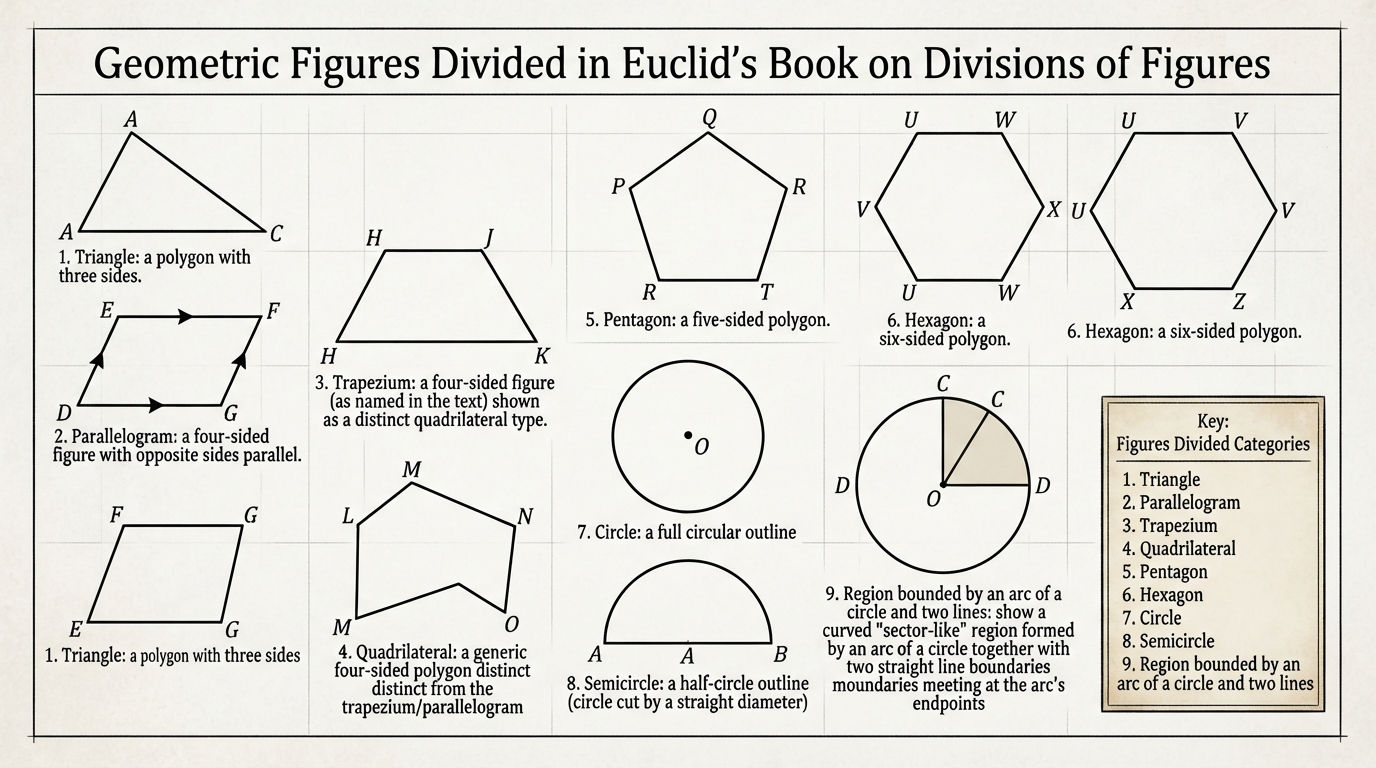

Generated image: /content/euclid_image_d2831d56.jpeg


PosixPath('/content/euclid_image_d2831d56.jpeg')

In [42]:
ask_ai(
    "Create an educational image showing the types of geometric figures divided in Euclid's treatise."
)

## Test Case 8 — Audio

In [43]:
ask_ai(
    "Read aloud a concise explanation of what Euclid's Book on Divisions of Figures is about."
)

Intermediate structured response:
prompt="Provide a concise read-aloud explanation of what Euclid's Book on Divisions of Figures is about." format='audio'

The retrieve_information tool was called.

Text prepared for audio:
Euclid’s Book on Divisions of Figures is about dividing one given geometric figure into other figures. In general, the divisions are into figures of the same kind as the original, like dividing triangles into triangles. But it also includes divisions into “unlike” figures, such as dividing a triangle by a straight line parallel to its base. The book also includes missing propositions about dividing a circle, including ways “to divide into two equal parts” a given figure bounded by a circular arc and two straight lines with a given angle, and ways “to draw in a given circle two parallel straight lines” that cut off a certain part of the circle. According to the text, proofs are given for only four propositions out of thirty-six, because an Arabian translator left out

Generated audio: /content/euclid_audio_aabb4c41.mp3


PosixPath('/content/euclid_audio_aabb4c41.mp3')

## Test Case 9 — Follow-up audio

In [44]:
ask_ai(
    "Now explain the previous answer in more detail and return it as audio."
)

Intermediate structured response:
prompt='Explain in more detail what Euclid’s Book on Divisions of Figures is about, including its main theme of dividing a given geometric figure into parts (both like-kind and unlike-kind divisions), and the kinds of circular or arc-bounded divisions it includes (e.g., dividing into two equal parts when given a figure bounded by a circular arc and two straight lines with a specified angle, and related constructions with two parallel straight lines inside a given circle), plus the note that only four proofs out of thirty-six are included due to missing material from an Arabian translator and that several auxiliary propositions are introduced even though they are not used.' format='audio'

The retrieve_information tool was called.

Text prepared for audio:
Euclid’s Book on Divisions of Figures is concerned with the problem of dividing a given geometric figure into parts. In general, these are divisions “into figures of the same kind as the original figu

Generated audio: /content/euclid_audio_de6d0939.mp3


PosixPath('/content/euclid_audio_de6d0939.mp3')

## Test Case 10 — Additional image

Intermediate structured response:
prompt='Create a visualization that illustrates Euclid’s Book on Divisions of Figures describing how to divide a triangle into equal parts. Show a triangle split by appropriate lines into two or more regions that are equal in area (as the book intends by its method for equal division).' format='image'

The retrieve_information tool was called.

Verified image-generation context:
Show a single triangle labeled “abc” with its base “bc” and a point “d” chosen on (or within and then used with production of) the lines through the triangle’s sides “aef” and “hbl,” such that those lines divide the triangle equally. Include the main construction line “dp” drawn from “d” to meet “ca” at “p” (where “p” is obtained by producing “dk” to meet “ca”). Add the auxiliary lines “dg” drawn parallel to “ca” meeting “cb” produced in “g,” and the joining line “cd.” Depict the similarity-based internal step by marking that “mn” is chosen on “cd” so that the ratio of areas is

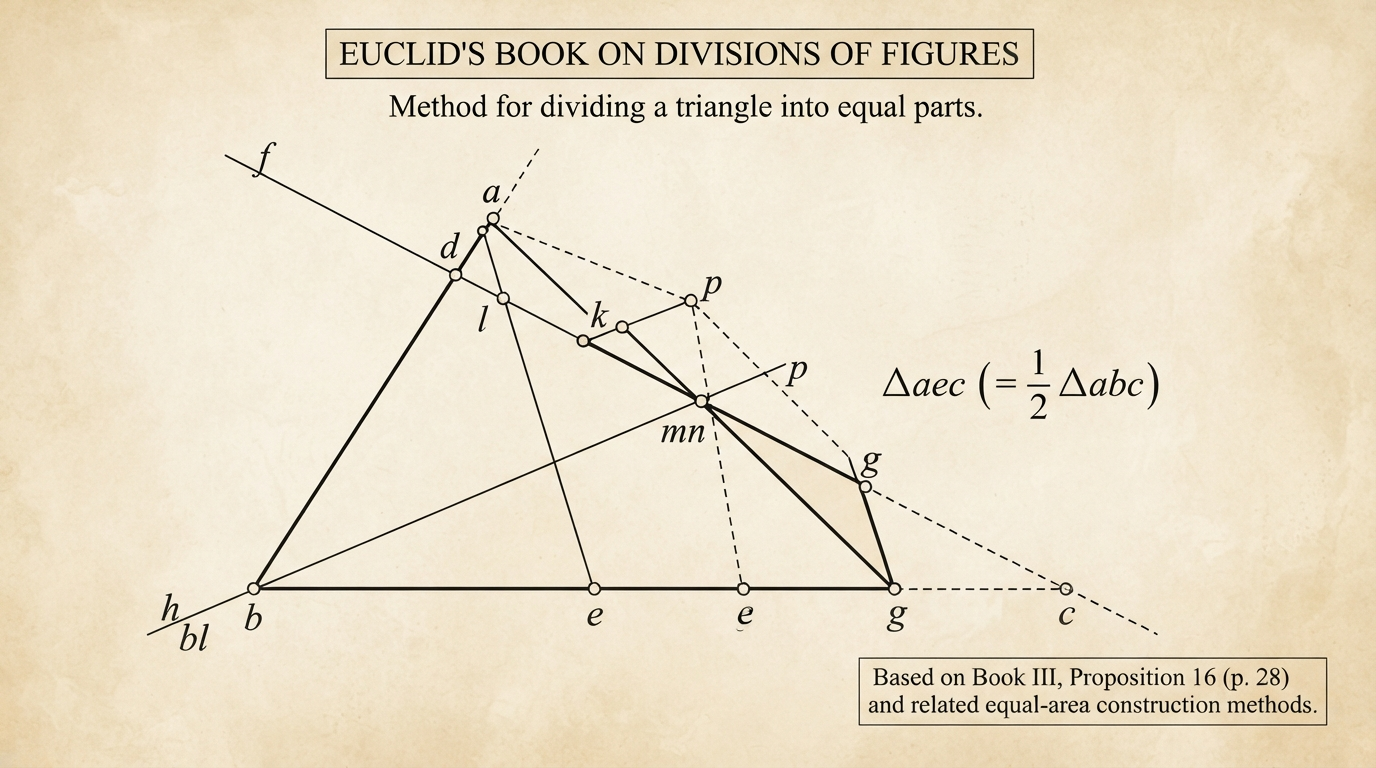

Generated image: /content/euclid_image_e9257029.jpeg


PosixPath('/content/euclid_image_e9257029.jpeg')

In [45]:
ask_ai(
    "Visualize the document's description of dividing a triangle into equal parts."
)

## Inspect conversation history

In [46]:
show_conversation_history()

1. USER
What is Euclid's Book on Divisions of Figures about? Give me a text answer.
----------------------------------------------------------------------
2. ASSISTANT
Euclid’s *Book on Divisions of Figures* is about dividing given geometric figures into smaller parts. In general, the divisions are into figures of the same kind as the original (for example, dividing triangles into triangles), but the work also includes divisions into “unlike” figures—such as dividing a triangle by a straight line parallel to its base (described as a division into unlike figures). It also contains propositions about dividing a circle, including: dividing a figure bounded by an arc of a circle and two straight lines (with a given angle) into two equal parts, and drawing two parallel straight lines in a given circle that cut off a certain part of the circle. According to the discussion in the text, proofs are given for only four propositions out of 36 (with the others omitted in a way attributed to an Ara

## Clear conversation history

In [47]:
reset_conversation()

Conversation history has been cleared.
